# **IMDB Movie Dataset Analysist**


# Project Objectives

This is formatted as code
The main objective is to clean,
analyze, visualize, and extract meaningful insights from IMDB movie data using Python and MySQL.




# Import Required Libraries

In [115]:
!pip install mysql-connector-python

In [116]:
import pandas as pd

In [117]:
import mysql.connector

In [118]:
!apt-get update
!apt-get install -y mysql-server

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
mysql-server is already the newest version (8.0.46-0ubuntu0.22.04.3).
0 upgraded, 0 newly inst

In [119]:
!service mysql start
!service mysql status

 * Starting MySQL database server mysqld
   ...done.
 * /usr/bin/mysqladmin  Ver 8.0.46-0ubuntu0.22.04.3 for Linux on x86_64 ((Ubuntu))
Copyright (c) 2000, 2026, Oracle and/or its affiliates.

Oracle is a registered trademark of Oracle Corporation and/or its
affiliates. Other names may be trademarks of their respective
owners.

Server version		8.0.46-0ubuntu0.22.04.3
Protocol version	10
Connection		Localhost via UNIX socket
UNIX socket		/var/run/mysqld/mysqld.sock
Uptime:			2 hours 15 min 7 sec

Threads: 4  Questions: 141  Slow queries: 0  Opens: 243  Flush tables: 3  Open tables: 162  Queries per second avg: 0.017


In [120]:
!
# Use the debian-sys-maint user (whose credentials are in /etc/mysql/debian.cnf)
# to log in and set the root user's password. This is a more robust approach
# when direct `ALTER USER` commands for 'root' fail in Colab environments.
!mysql --defaults-extra-file=/etc/mysql/debian.cnf -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'root';"

# Then, flush privileges for the new password to take effect.
!mysql --defaults-extra-file=/etc/mysql/debian.cnf -e "FLUSH PRIVILEGES;"

# Verify login with the new password for the root user.
!mysql -u root -proot -e "SELECT 'MySQL login successful';"

print("MySQL user 'root'@'localhost' password set and privileges flushed using debian-sys-maint.")

mysql: [Warning] Using a password on the command line interface can be insecure.
+------------------------+
| MySQL login successful |
+------------------------+
| MySQL login successful |
+------------------------+
MySQL user 'root'@'localhost' password set and privileges flushed using debian-sys-maint.


Connecting mysql

In [121]:
import mysql.connector


conn = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="root",
    database="Movie",
    auth_plugin="mysql_native_password"
)


print("Connected successfully!")

Connected successfully!


# Load Raw the Dataset

In [122]:
from google.colab import files

uploaded = files.upload()

Saving imdb_movies.csv to imdb_movies (3).csv


# Data Cleaning and Preprocessing

In [123]:
import pandas as pd

# ==================================================
# 1. LOAD DATA
# ==================================================

df = pd.read_csv("imdb_movies.csv")

print("Original Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ==================================================
# 2. CLEAN TEXT COLUMNS
# ==================================================

df["title"] = df["title"].str.strip()

df["genre"] = df["genre"].str.strip()

df["director"] = df["director"].str.strip()

df["lead_actor"] = df["lead_actor"].str.strip()


# ==================================================
# BR-04: MISSING DIRECTOR / ACTOR
# NULL → Unknown
# ==================================================

df["director"] = df["director"].fillna("Unknown")

df["lead_actor"] = df["lead_actor"].fillna("Unknown")

# Also handle empty strings

df["director"] = df["director"].replace("", "Unknown")

df["lead_actor"] = df["lead_actor"].replace("", "Unknown")


# ==================================================
# 3. CONVERT NUMERIC COLUMNS
# ==================================================

df["release_year"] = pd.to_numeric(
    df["release_year"],
    errors="coerce"
)

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

df["budget_million"] = pd.to_numeric(
    df["budget_million"],
    errors="coerce"
)

df["gross_million"] = pd.to_numeric(
    df["gross_million"],
    errors="coerce"
)


# ==================================================
# BR-03: RATING
# Rating must be between 0 and 10
# ==================================================

df.loc[
    (df["rating"] < 0) |
    (df["rating"] > 10),
    "rating"
] = None


# ==================================================
# BR-03: MISSING RATING
# Replace with genre-wise average
# ==================================================

genre_average = (
    df.groupby("genre")["rating"]
    .transform("mean")
)

df["rating"] = df["rating"].fillna(
    genre_average
)


# ==================================================
# BR-01: DUPLICATE MOVIES
#
# Same title + release_year
# 1. Highest rating
# 2. If rating same → highest gross
# ==================================================

df = df.sort_values(
    by=[
        "title",
        "release_year",
        "rating",
        "gross_million"
    ],
    ascending=[
        True,
        True,
        False,
        False
    ]
)

df = df.drop_duplicates(
    subset=[
        "title",
        "release_year"
    ],
    keep="first"
)


# ==================================================
# BR-02: MOVIE ID
# Unique and non-null
# ==================================================

df = df.reset_index(drop=True)

df["movie_id"] = range(
    1,
    len(df) + 1
)


# ==================================================
# 4. FINAL VALIDATION
# ==================================================

print("\n==============================")
print("FINAL VALIDATION")
print("==============================")


print("\nFinal Shape:")
print(df.shape)


print("\nMissing Values:")
print(df.isnull().sum())


print("\nDuplicate Movies:")
print(
    df.duplicated(
        subset=[
            "title",
            "release_year"
        ]
    ).sum()
)


print("\nDuplicate Movie IDs:")
print(
    df["movie_id"].duplicated().sum()
)


print("\nMissing Movie IDs:")
print(
    df["movie_id"].isnull().sum()
)


print("\nInvalid Ratings:")
print(
    (
        (df["rating"] < 0) |
        (df["rating"] > 10)
    ).sum()
)


# ==================================================
# 5. VIEW CLEANED DATA
# ==================================================

print("\nCleaned Data:")

display(df.head(10))


# ==================================================
# 6. SAVE CLEANED DATA
# ==================================================

df.to_csv(
    "imdb_movies_cleaned.csv",
    index=False
)

print(
    "\nCleaned file saved as: "
    "imdb_movies_cleaned.csv"
)

Original Shape: (5500, 9)

Columns:
['movie_id', 'title', 'genre', 'rating', 'budget_million', 'gross_million', 'director', 'lead_actor', 'release_year']

FINAL VALIDATION

Final Shape:
(5473, 9)

Missing Values:
movie_id            0
title               0
genre               0
rating              0
budget_million    928
gross_million     913
director            0
lead_actor          0
release_year      610
dtype: int64

Duplicate Movies:
0

Duplicate Movie IDs:
0

Missing Movie IDs:
0

Invalid Ratings:
0

Cleaned Data:


,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1,Movie 1,Thriller,4.200000,100.0,NaN,Cameron,Unknown,2017.0
1,2,Movie 10,Sci-Fi,5.000000,NaN,20.0,Spielberg,Actor B,2019.0
2,3,Movie 1001,Comedy,6.400000,NaN,20.0,Rajamouli,Actor D,2021.0
3,4,Movie 1002,Comedy,7.600000,60.0,150.0,Cameron,Unknown,NaN
4,5,Movie 1003,Sci-Fi,9.100000,150.0,150.0,Spielberg,Actor C,2019.0
5,6,Movie 1004,Action,7.200000,10.0,80.0,Unknown,Actor B,2015.0
6,7,Movie 1005,Thriller,4.000000,30.0,NaN,Spielberg,Actor D,2015.0
7,8,Movie 1006,Horror,9.200000,NaN,300.0,Unknown,Actor D,2021.0
8,9,Movie 1007,Horror,6.408612,30.0,300.0,Rajamouli,Actor A,2015.0
9,10,Movie 1008,Horror,7.200000,NaN,150.0,Spielberg,Actor A,NaN



Cleaned file saved as: imdb_movies_cleaned.csv


In [124]:
from google.colab import files

uploaded = files.upload()

Saving imdb_movies_cleaned.csv to imdb_movies_cleaned (3).csv


In [125]:
import pandas as pd

# Load the cleaned data from the CSV file
df_to_insert = pd.read_csv("imdb_movies_cleaned.csv")

cursor = conn.cursor()

# Prepare the INSERT statement dynamically based on DataFrame columns
# Exclude the auto-increment 'id' column from the insertion list, if it exists in the SQL table but not in DataFrame
# The DataFrame 'df_to_insert' already has a 'movie_id' column which should be inserted into the 'movie_id' column of the SQL table.
columns = ', '.join([f'`{col}`' for col in df_to_insert.columns])
placeholders = ', '.join(['%s'] * len(df_to_insert.columns))
insert_query = f"INSERT INTO imdb_movies ({columns}) VALUES ({placeholders})"

# Prepare the data for insertion
data_to_insert = [tuple(row) for row in df_to_insert.values]

try:
    # Execute the insert query for all rows at once using executemany
    cursor.executemany(insert_query, data_to_insert)
    conn.commit()
    print(f"Successfully inserted {cursor.rowcount} rows into 'imdb_movies'.")
except mysql.connector.Error as err:
    print(f"Error inserting data: {err}")
finally:
    cursor.close()
    # You might want to keep the connection open for subsequent SQL analytics,
    # but for now, we'll close it if we're done with this step.
    # conn.close() # Do not close if you intend to run more queries.

Successfully inserted 5473 rows into 'imdb_movies'.


# SQL Analytics

In [126]:
cursor = conn.cursor()

create_table_query = """
CREATE TABLE IF NOT EXISTS imdb_movies (
    id INT AUTO_INCREMENT PRIMARY KEY,
    movie_id INT,
    title VARCHAR(255),
    genre VARCHAR(255),
    rating FLOAT,
    budget_million FLOAT,
    gross_million FLOAT,
    director VARCHAR(255),
    lead_actor VARCHAR(255),
    release_year INT
);
"""

try:
    cursor.execute(create_table_query)
    conn.commit()
    print("Table 'imdb_movies' created successfully or already exists.")
except mysql.connector.Error as err:
    print(f"Error creating table: {err}")
finally:
    cursor.close()

Table 'imdb_movies' created successfully or already exists.


In [127]:
sql_query_top_grossing = """
WITH RankedMovies AS (
    SELECT
        title,
        release_year,
        gross_million,
        ROW_NUMBER() OVER (PARTITION BY release_year ORDER BY gross_million DESC) as rn
    FROM
        imdb_movies
    WHERE
        release_year IS NOT NULL AND gross_million IS NOT NULL
)
SELECT
    title,
    release_year,
    gross_million
FROM
    RankedMovies
WHERE
    rn <= 10
ORDER BY
    release_year DESC, gross_million DESC;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_top_grossing)
    top_grossing_movies_by_year = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    top_grossing_df = pd.DataFrame(top_grossing_movies_by_year, columns=['title', 'release_year', 'gross_million'])
    print("Top 10 highest-grossing movies by year (from MySQL):")
    print(top_grossing_df.head(20)) # Print first 20 to show a couple of years
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Top 10 highest-grossing movies by year (from MySQL):
         title  release_year  gross_million
0   Movie 2817          2022          600.0
1   Movie 2787          2022          600.0
2   Movie 2784          2022          600.0
3   Movie 2765          2022          600.0
4   Movie 2714          2022          600.0
5   Movie 2691          2022          600.0
6   Movie 2690          2022          600.0
7   Movie 2656          2022          600.0
8   Movie 2655          2022          600.0
9   Movie 2637          2022          600.0
10   Movie 933          2021          600.0
11   Movie 937          2021          600.0
12   Movie 969          2021          600.0
13   Movie 993          2021          600.0
14  Movie 1127          2021          600.0
15   Movie 123          2021          600.0
16  Movie 1324          2021          600.0
17  Movie 1467          2021          600.0
18   Movie 160          2021          600.0
19  Movie 1157          2021          600.0


In [128]:
sql_query_genre_avg_rating = """
SELECT
    genre,
    AVG(rating) AS average_rating
FROM
    imdb_movies
WHERE
    genre IS NOT NULL AND rating IS NOT NULL
GROUP BY
    genre
ORDER BY
    average_rating DESC;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_genre_avg_rating)
    genre_avg_ratings = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    genre_avg_ratings_df = pd.DataFrame(genre_avg_ratings, columns=['genre', 'average_rating'])
    print("Average rating distribution across genres (from MySQL):")
    print(genre_avg_ratings_df)
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Average rating distribution across genres (from MySQL):
      genre  average_rating
0    Sci-Fi        6.639906
1    Action        6.582924
2  Thriller        6.520403
3   Fantasy        6.506774
4   Romance        6.478025
5    Comedy        6.472408
6     Drama        6.465472
7    Horror        6.419315


In [129]:
sql_query_top_directors = """
SELECT
    director,
    AVG(rating) AS average_rating
FROM
    imdb_movies
WHERE
    director IS NOT NULL AND director != 'Unknown' AND rating IS NOT NULL
GROUP BY
    director
ORDER BY
    average_rating DESC
LIMIT 5;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_top_directors)
    top_directors_data = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    top_directors_df = pd.DataFrame(top_directors_data, columns=['director', 'average_rating'])
    print("Top 5 directors by average movie rating (from MySQL):")
    print(top_directors_df)
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Top 5 directors by average movie rating (from MySQL):
    director  average_rating
0   Scorsese        6.589650
1  Spielberg        6.580560
2  Tarantino        6.519149
3      Nolan        6.454822
4    Cameron        6.428931


In [130]:
sql_query_budget_gross = """
SELECT
    budget_million,
    gross_million
FROM
    imdb_movies
WHERE
    budget_million IS NOT NULL AND gross_million IS NOT NULL;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_budget_gross)
    budget_gross_data = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    budget_gross_df = pd.DataFrame(budget_gross_data, columns=['budget_million', 'gross_million'])
    print("Sample of Budget vs Gross data (from MySQL):")
    print(budget_gross_df.head())

    # Calculate correlation
    correlation = budget_gross_df['budget_million'].corr(budget_gross_df['gross_million'])
    print(f"\nCorrelation between Budget and Gross: {correlation:.2f}")
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Sample of Budget vs Gross data (from MySQL):
   budget_million  gross_million
0            60.0          150.0
1           150.0          150.0
2            10.0           80.0
3            30.0          300.0
4            10.0           20.0

Correlation between Budget and Gross: 0.01


In [131]:
sql_query_profitable_genre = """
SELECT
    genre,
    AVG(gross_million - budget_million) AS average_profit_million
FROM
    imdb_movies
WHERE
    gross_million IS NOT NULL AND budget_million IS NOT NULL
GROUP BY
    genre
ORDER BY
    average_profit_million DESC
LIMIT 5;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_profitable_genre)
    profitable_genre_data = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    profitable_genre_df = pd.DataFrame(profitable_genre_data, columns=['genre', 'average_profit_million'])
    print("Top 5 most profitable genres (from MySQL):")
    print(profitable_genre_df)
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Top 5 most profitable genres (from MySQL):
      genre  average_profit_million
0     Drama              166.215054
1  Thriller              165.195876
2   Fantasy              164.107060
3    Action              163.938011
4    Sci-Fi              160.912863


# Matplotlib **Dashboards**

1. Identify Top 10 highest grossing movies by year.


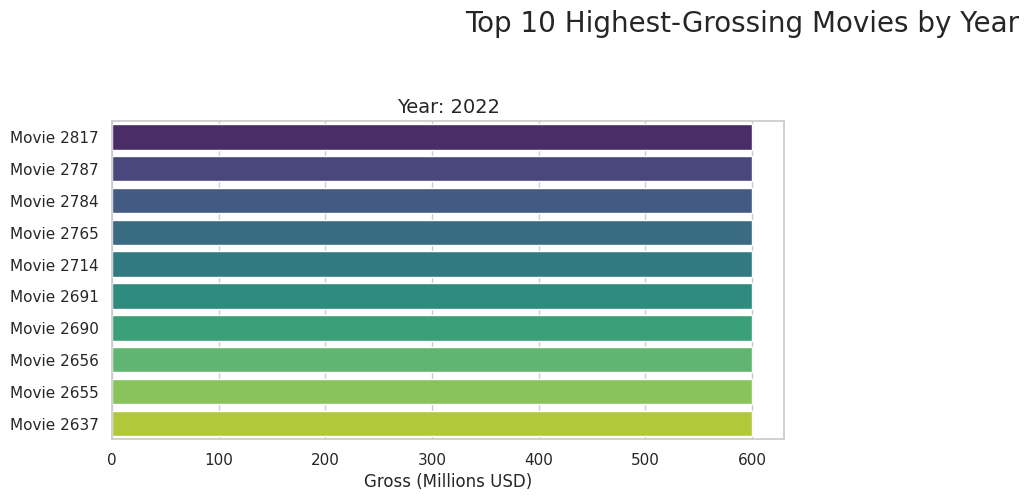

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the data is sorted
top_grossing_df_sorted = top_grossing_df.sort_values(by=['release_year', 'gross_million'], ascending=[False, False])

# Filter for the most recent 5 years to keep the visualization clear
unique_years = sorted(top_grossing_df_sorted['release_year'].unique(), reverse=True)[:1]

plt.figure(figsize=(15, 12))
plt.suptitle('Top 10 Highest-Grossing Movies by Year', fontsize=20, y=1.02)

for i, year in enumerate(unique_years):
    plt.subplot(3, 2, i + 1)
    year_data = top_grossing_df_sorted[top_grossing_df_sorted['release_year'] == year].head(10)
    sns.barplot(
        x='gross_million',
        y='title',
        data=year_data,
        palette='viridis',
        hue='title',
        legend=False
    )
    plt.title(f'Year: {int(year)}', fontsize=14)
    plt.xlabel('Gross (Millions USD)')
    plt.ylabel('')
    plt.xlim(0, 3000) # Set x-axis limit to 3000

plt.tight_layout()
plt.show()

2. Show rating distribution across genres.


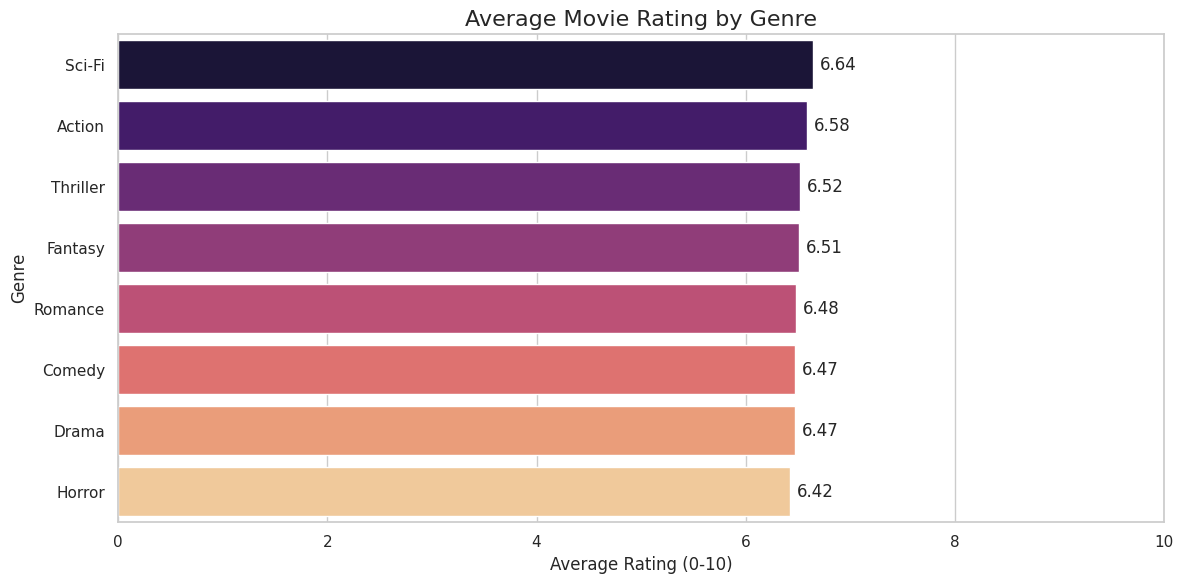

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the bar plot for Average Rating Distribution Across Genres
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='average_rating',
    y='genre',
    data=genre_avg_ratings_df,
    palette='magma',
    hue='genre',
    legend=False
)

# Add details to the plot
plt.title('Average Movie Rating by Genre', fontsize=16)
plt.xlabel('Average Rating (0-10)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xlim(0, 10)  # Standard IMDB rating scale

# Add the rating values as text labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.tight_layout()
plt.show()

3. Find Top 5 directors by average movie rating.


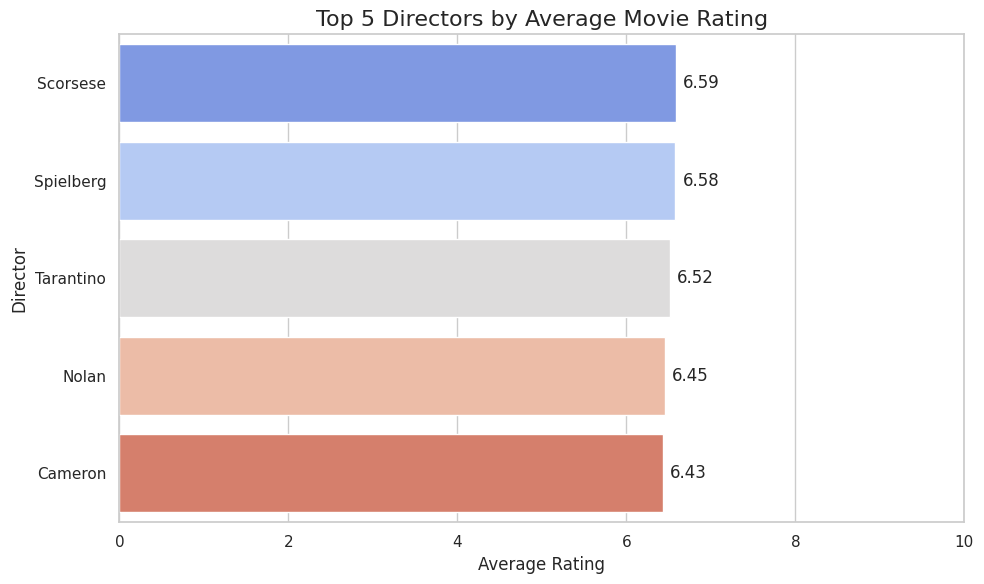

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the bar plot for Top 5 Directors
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='average_rating',
    y='director',
    data=top_directors_df,
    palette='coolwarm',
    hue='director',
    legend=False
)

# Add details to the plot
plt.title('Top 5 Directors by Average Movie Rating', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.xlim(0, 10)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.tight_layout()
plt.show()

4. Analyze budget vs gross correlation.

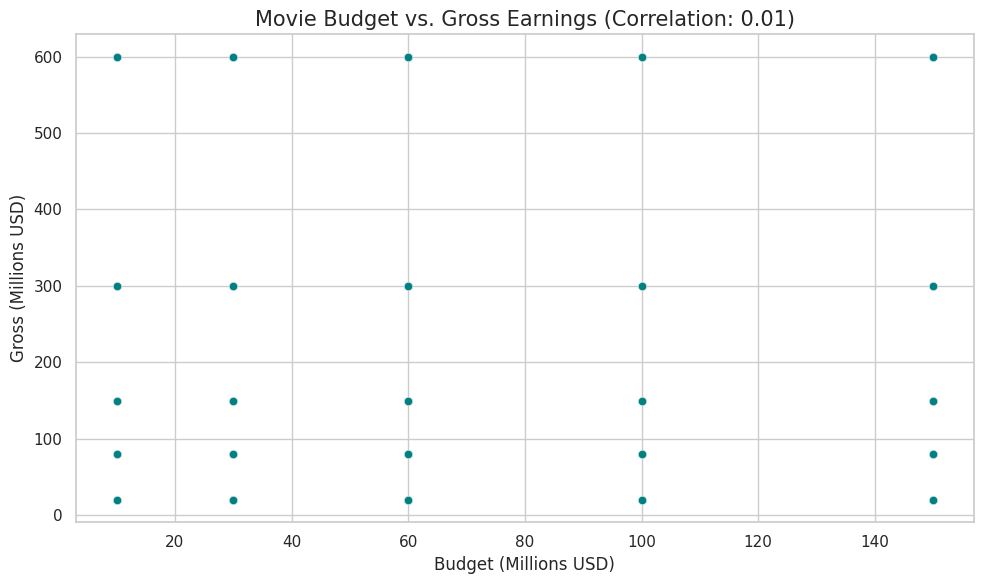

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=budget_gross_df,
    x='budget_million',
    y='gross_million',
    alpha=0.6,
    color='teal'
)

# Calculate correlation for the title
correlation = budget_gross_df['budget_million'].corr(budget_gross_df['gross_million'])

# Add labels and title
plt.title(f'Movie Budget vs. Gross Earnings (Correlation: {correlation:.2f})', fontsize=15)
plt.xlabel('Budget (Millions USD)', fontsize=12)
plt.ylabel('Gross (Millions USD)', fontsize=12)

plt.tight_layout()
plt.show()

5. Identify most profitable genre.


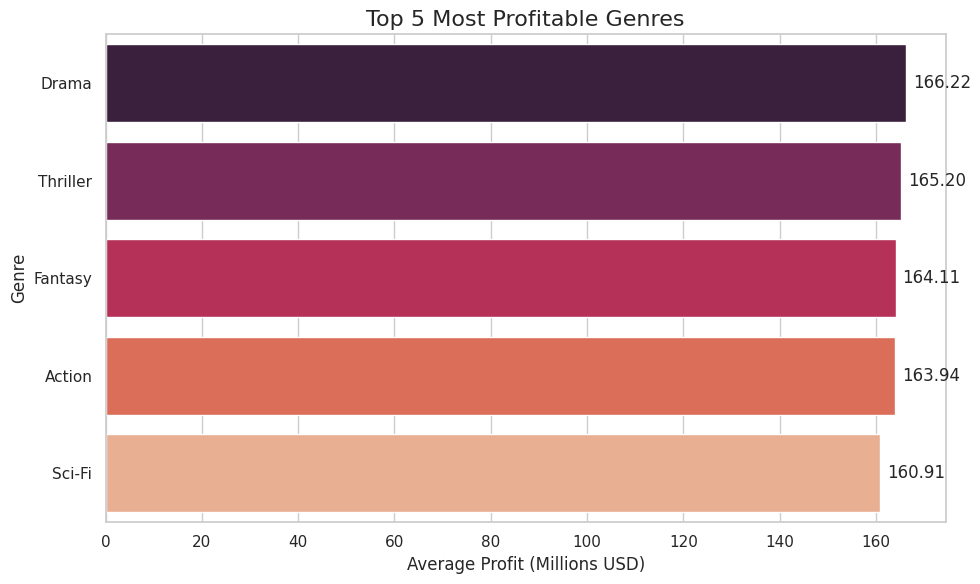

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the bar plot for Most Profitable Genres
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='average_profit_million',
    y='genre',
    data=profitable_genre_df,
    palette='rocket',
    hue='genre',
    legend=False
)

# Add details to the plot
plt.title('Top 5 Most Profitable Genres', fontsize=16)
plt.xlabel('Average Profit (Millions USD)', fontsize=12)
plt.ylabel('Genre', fontsize=12)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.tight_layout()
plt.show()

# Conclusion

The IMDB Movie Dataset Analysis successfully cleaned and analyzed movie data using Python, MySQL, Pandas, NumPy, and Matplotlib. The analysis helped identify trends in movie ratings, genres, budgets, revenue, and other factors. SQL analytics and visualizations provided meaningful insights that can support better decision-making in the movie industry.